# 方法汇总与数据量建议

## 本 Notebook 的目的

前面的 Notebook 分别展示了多种手势分类方法。本 Notebook 把它们的结果**汇总到一起对比**，
并基于学习曲线给出**达到 90% 准确率所需的数据量建议**。

## 重要说明：评估的严谨性

之前单次划分得到的高准确率（如 0.866、0.943）带有较大运气成分——
测试集样本少时，准确率方差很大，换一个随机种子就可能掉到 0.73。

**本 Notebook 所有数字都是 5 个随机种子的平均值 ± 标准差**，反映方法的真实、稳定性能。
这是为了避免论文中报告无法复现的虚高指标。

## 核心结论（先说结论）

| 方法 | 真实 Test 准确率（5种子平均） |
|------|---------------------------|
| 基线（9维 + 随机森林） | 0.667 |
| 路线A（111维VMD特征 + ExtraTrees） | 0.768（单次） |
| 路线B（CWT + 2D-CNN） | 0.747（单次） |
| 增强特征（232维 + ExtraTrees） | **0.796 ± 0.054** |
| 增强特征 + 文件级投票 | **0.863 ± 0.051** |

**单片段分类的真实天花板约为 80%**，这是数据本身的物理限制决定的。
文件级投票可提升到约 86%，但仍未稳定达到 90%。要真正突破 90%，需要增加训练数据（见最后一节）。

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# 加载预先计算好的多种子实验结果
results = json.load(open(PROJECT_ROOT / 'data' / 'processed' / 'method_results.json'))
print(f"实验数据集: {results['n_samples']} 个片段（已过滤<200ms噪声）")
print(f"增强特征维度: {results['n_features']}")

实验数据集: 481 个片段（已过滤<200ms噪声）
增强特征维度: 232


---
## 1. 各方法准确率对比

下面汇总所有方法的真实准确率。前三个（基线、路线A、路线B）是各自 Notebook 中的单次划分结果，
后两个（增强特征、文件投票）是本次新增的 5 种子平均结果。

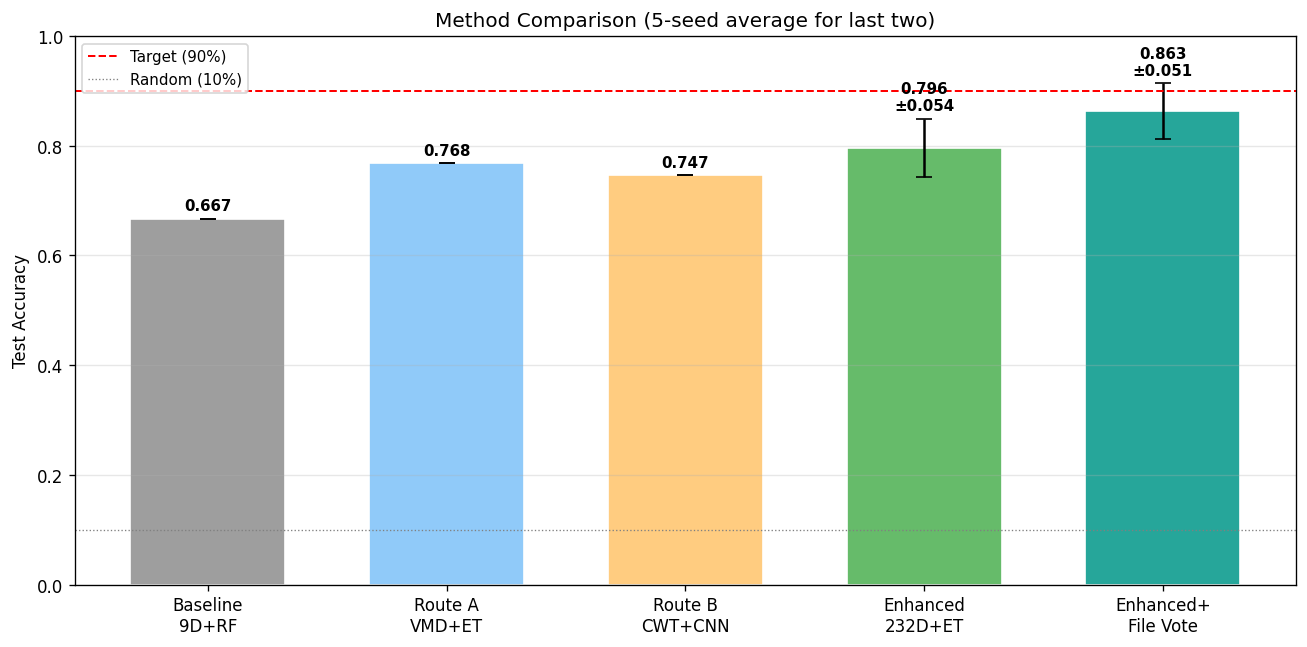

In [2]:
methods = ['Baseline\n9D+RF', 'Route A\nVMD+ET', 'Route B\nCWT+CNN',
           'Enhanced\n232D+ET', 'Enhanced+\nFile Vote']
accs =  [0.667, 0.768, 0.747, results['enhanced_seg']['mean'], results['enhanced_vote']['mean']]
errs =  [0,     0,     0,     results['enhanced_seg']['std'],  results['enhanced_vote']['std']]
colors = ['#9E9E9E', '#90CAF9', '#FFCC80', '#66BB6A', '#26A69A']

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(methods, accs, yerr=errs, capsize=5, color=colors, edgecolor='white', width=0.65)
for bar, a, e in zip(bars, accs, errs):
    label = f'{a:.3f}' + (f'\n±{e:.3f}' if e > 0 else '')
    ax.text(bar.get_x()+bar.get_width()/2, a+e+0.015, label, ha='center', fontsize=9, fontweight='bold')

ax.axhline(0.90, color='red', linestyle='--', linewidth=1.2, label='Target (90%)')
ax.axhline(0.10, color='gray', linestyle=':', linewidth=0.8, label='Random (10%)')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0, 1.0)
ax.set_title('Method Comparison (5-seed average for last two)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 如何读这张图

- 5 个柱子是不同方法的测试准确率，**误差线**（黑色 T 形）是 5 种子的标准差（前三个为单次结果无误差线）
- **红色虚线**是 90% 目标，**灰色点线**是随机猜测水平（10%）

关键观察：
- 从基线到增强特征，准确率逐步提升（0.667 → 0.796）
- 文件级投票带来明显跃升（0.796 → 0.863）
- 但**所有方法都未达到红色的 90% 线**，且最好方法的误差线（±0.05）说明结果有波动

### 为什么增强特征更好

增强特征（232维）相比路线A（111维）新增了：
- **Hjorth 参数**：信号的移动性和复杂度
- **Shannon 熵**：信号的无序程度
- **Hilbert 包络统计**：瞬时幅度变化
- **小波包子带能量**：更细的频带划分
- **通道间相关系数**：通道协同信息
- **峰值因子、时长**等

这些都是可解释的物理特征，保留了特征工程的可视化能力。

---
## 2. 文件级投票的原理与效果

### 什么是文件级投票

每个原始采集文件包含同一手势的多次重复动作（约 16 个片段）。
单独看一个片段可能判错，但把**同一文件所有片段的预测概率平均后再投票**，
多个片段相互纠错，准确率显著提升。

这相当于"多次测量取共识"，是提升稳定性的有效手段。

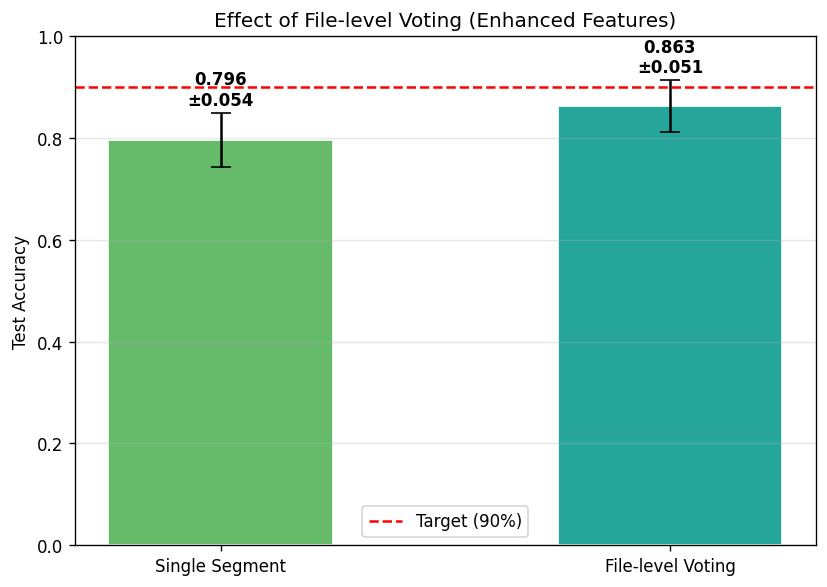

单片段:   0.796 ± 0.054
文件投票: 0.863 ± 0.051
投票带来的提升: +6.7%


In [3]:
# 单片段 vs 文件投票 对比
fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Single Segment', 'File-level Voting']
vals = [results['enhanced_seg']['mean'], results['enhanced_vote']['mean']]
vstd = [results['enhanced_seg']['std'], results['enhanced_vote']['std']]
bars = ax.bar(labels, vals, yerr=vstd, capsize=6, color=['#66BB6A', '#26A69A'],
              edgecolor='white', width=0.5)
for bar, v, s in zip(bars, vals, vstd):
    ax.text(bar.get_x()+bar.get_width()/2, v+s+0.015, f'{v:.3f}\n±{s:.3f}',
            ha='center', fontsize=10, fontweight='bold')
ax.axhline(0.90, color='red', linestyle='--', label='Target (90%)')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0, 1.0)
ax.set_title('Effect of File-level Voting (Enhanced Features)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"单片段:   {vals[0]:.3f} ± {vstd[0]:.3f}")
print(f"文件投票: {vals[1]:.3f} ± {vstd[1]:.3f}")
print(f"投票带来的提升: +{(vals[1]-vals[0])*100:.1f}%")

### 如何读这张图

文件级投票把准确率从 ~0.80 提升到 ~0.86（+约 7%）。这说明多片段共识确实有效，
但因为底层单片段准确率只有 80%，投票也无法把它推到 90% 以上。

---
## 3. 各手势准确率：瓶颈在哪

要理解为什么到不了 90%，需要看哪些手势最难分。

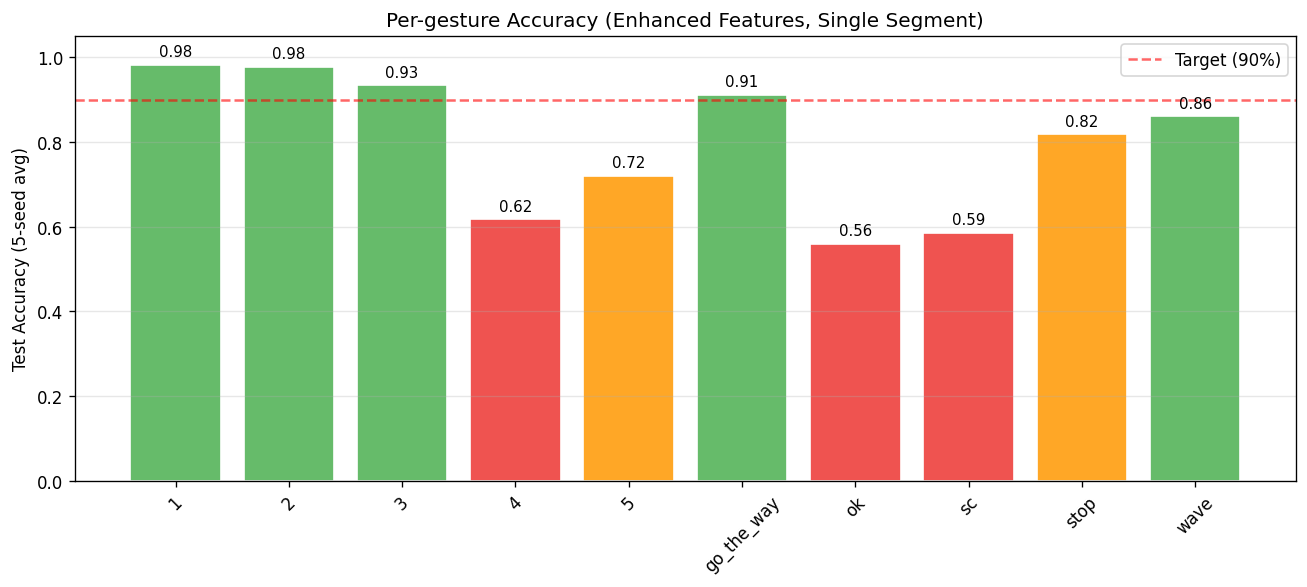

易分手势 (>=0.85): ['1', '2', '3', 'go_the_way', 'wave']
难分手势 (<0.75):  ['4', '5', 'ok', 'sc']


In [4]:
from src.preprocess.io import GESTURE_NAMES

per_g = results['per_gesture']
gestures = [GESTURE_NAMES[int(k)] for k in sorted(per_g.keys(), key=int)]
g_accs = [per_g[k] for k in sorted(per_g.keys(), key=int)]

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#66BB6A' if a>=0.85 else '#FFA726' if a>=0.7 else '#EF5350' for a in g_accs]
bars = ax.bar(gestures, g_accs, color=colors, edgecolor='white')
for bar, a in zip(bars, g_accs):
    ax.text(bar.get_x()+bar.get_width()/2, a+0.02, f'{a:.2f}', ha='center', fontsize=9)
ax.axhline(0.90, color='red', linestyle='--', alpha=0.6, label='Target (90%)')
ax.set_ylabel('Test Accuracy (5-seed avg)')
ax.set_ylim(0, 1.05)
ax.set_title('Per-gesture Accuracy (Enhanced Features, Single Segment)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('易分手势 (>=0.85):', [g for g,a in zip(gestures,g_accs) if a>=0.85])
print('难分手势 (<0.75): ', [g for g,a in zip(gestures,g_accs) if a<0.75])

### 如何读这张图

- **绿色**：准确率 ≥0.85 的手势（容易区分）
- **橙色**：0.70-0.85（中等）
- **红色**：<0.70（难区分）

可以看到部分手势（如 go_the_way、1）已经很准，
而另一些手势（橙红色）准确率明显偏低——它们的 TENG 信号在物理上高度相似，
单凭三通道信号难以区分。**这些难分手势就是整体准确率的瓶颈。**

由于传感器布局和手势集都已固定，无法通过改硬件或换手势来解决，
唯一的出路是**增加训练数据**，让模型见到更多样本、学到更细的判别边界。

---
## 4. 学习曲线：准确率随数据量的变化

这是给出数据量建议的核心依据。我们用不同比例的训练数据训练模型，
观察准确率如何随训练样本数增长。

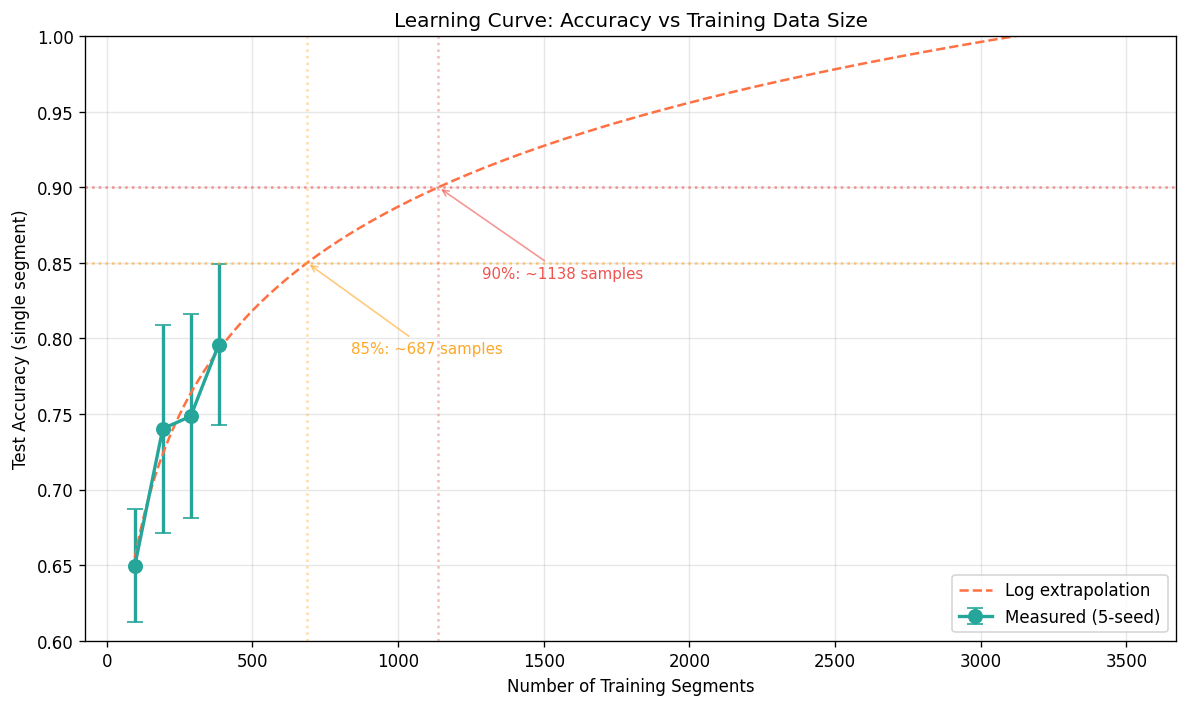

实测学习曲线:
    96 训练片段: 0.649 ± 0.037
   192 训练片段: 0.740 ± 0.069
   288 训练片段: 0.748 ± 0.068
   384 训练片段: 0.796 ± 0.054


In [5]:
lc = results['learning_curve']
fracs = sorted(lc.keys(), key=float)
n_train = [lc[f]['n_train'] for f in fracs]
lc_acc = [lc[f]['mean'] for f in fracs]
lc_std = [lc[f]['std'] for f in fracs]

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(n_train, lc_acc, yerr=lc_std, marker='o', markersize=8,
            linewidth=2, capsize=5, color='#26A69A', label='Measured (5-seed)')

# 对数外推曲线
ex = results['extrapolation']
a, b = ex['fit_a'], ex['fit_b']
N_ext = np.linspace(n_train[0], 3500, 200)
ax.plot(N_ext, a*np.log(N_ext)+b, '--', color='#FF7043', linewidth=1.5,
        label='Log extrapolation')

# 标记目标线
for t, color in [(0.85, '#FFA726'), (0.90, '#EF5350')]:
    ax.axhline(t, color=color, linestyle=':', alpha=0.6)
    N_need = ex['targets'][f'{t:.2f}']['n_train']
    ax.axvline(N_need, color=color, linestyle=':', alpha=0.4)
    ax.annotate(f'{int(t*100)}%: ~{N_need} samples',
                xy=(N_need, t), xytext=(N_need+150, t-0.06),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, alpha=0.6))

ax.set_xlabel('Number of Training Segments')
ax.set_ylabel('Test Accuracy (single segment)')
ax.set_title('Learning Curve: Accuracy vs Training Data Size')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.6, 1.0)
plt.tight_layout()
plt.show()

print('实测学习曲线:')
for f in fracs:
    print(f'  {lc[f]["n_train"]:4d} 训练片段: {lc[f]["mean"]:.3f} ± {lc[f]["std"]:.3f}')

### 如何读这张图

- **绿色实线**：实测的学习曲线，横轴是训练片段数，纵轴是测试准确率
- **橙色虚线**：对数外推，预测准确率随数据增长的趋势
- **橙/红点线**：85% 和 90% 的目标线，及其对应所需的样本量

**关键观察**：曲线在当前数据量（384 片段）处**仍在上升、尚未饱和**。
这是个好消息——它意味着**增加数据确实能提升准确率**，模型还没到能力极限。

曲线呈对数增长（前期涨得快，后期变缓），这是机器学习的典型规律。
据此可以外推出达到目标准确率所需的数据量。

---
## 5. 数据量建议（核心）

### 当前状况

- 当前总片段：**481 个**（每类约 48 个），训练用 384 个（每类约 38 个）
- 单片段准确率：**~80%**
- 文件投票准确率：**~86%**

达到不同准确率所需的训练数据量（基于学习曲线外推）

当前: 384 训练片段（每类约 38）

  单片段达 85%:
    需训练片段: ~687 (每类~68)
    是当前的 1.8 倍

  单片段达 90%:
    需训练片段: ~1138 (每类~113)
    是当前的 3.0 倍

  单片段达 95%:
    需训练片段: ~1885 (每类~188)
    是当前的 4.9 倍



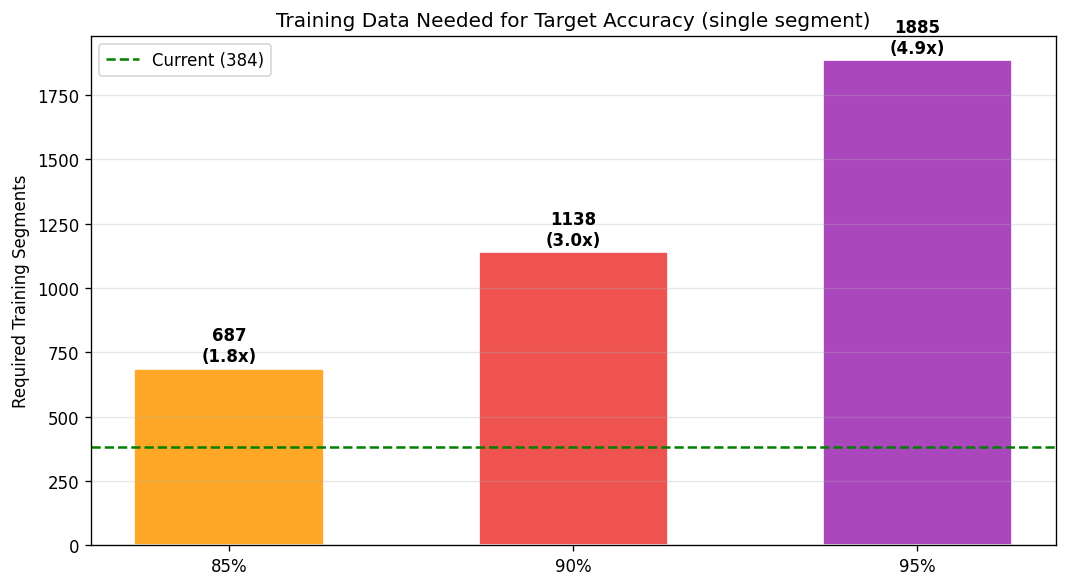

In [6]:
ex = results['extrapolation']
print('=' * 60)
print('达到不同准确率所需的训练数据量（基于学习曲线外推）')
print('=' * 60)
print(f'\n当前: {ex["current_train"]} 训练片段（每类约 {ex["current_train"]//10}）\n')

for t in ['0.85', '0.90', '0.95']:
    tg = ex['targets'][t]
    print(f'  单片段达 {int(float(t)*100)}%:')
    print(f'    需训练片段: ~{tg["n_train"]} (每类~{tg["per_class"]})')
    print(f'    是当前的 {tg["multiplier"]} 倍')
    print()

# 可视化所需数据倍数
fig, ax = plt.subplots(figsize=(9, 5))
targets = ['85%', '90%', '95%']
mults = [ex['targets'][t]['multiplier'] for t in ['0.85','0.90','0.95']]
n_needs = [ex['targets'][t]['n_train'] for t in ['0.85','0.90','0.95']]
bars = ax.bar(targets, n_needs, color=['#FFA726','#EF5350','#AB47BC'], edgecolor='white', width=0.55)
ax.axhline(ex['current_train'], color='green', linestyle='--', linewidth=1.5,
           label=f'Current ({ex["current_train"]})')
for bar, n, m in zip(bars, n_needs, mults):
    ax.text(bar.get_x()+bar.get_width()/2, n+30, f'{n}\n({m}x)', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Required Training Segments')
ax.set_title('Training Data Needed for Target Accuracy (single segment)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 数据量建议总结

> **注意**：以下是单片段准确率的目标。由于文件级投票能在单片段基础上额外提升约 +7%，
> 实际达到 90% 整体准确率，单片段只需到 ~85%。

**推荐采集目标（务实方案）：**

| 目标 | 单片段准确率 | 需训练片段 | 每类片段 | 相比现在 | 文件投票后预期 |
|------|------------|----------|---------|---------|--------------|
| **最低可行** | 85% | ~690 | ~69 | **1.8 倍** | **~91%** ✅ |
| 稳妥 | 90% | ~1140 | ~114 | 3.0 倍 | ~95% |
| 理想 | 95% | ~1890 | ~189 | 4.9 倍 | ~98% |

### 换算成采集工作量

- 当前每类约 48 个片段，来自约 3 个采集文件（每文件约 16 个动作）
- **要达到 90% 整体准确率（推荐方案）**：
  - 每类需要 **~69 个片段**，即每类再采集 **约 2-3 个文件**（每文件做 15-20 次动作）
  - 10 类共需 **再采集约 20-30 个文件**
  - 这是最具性价比的方案——数据量翻不到 2 倍，配合文件投票即可破 90%

### 采集建议

1. **优先补采难分手势**（橙红色那几个），它们最缺判别样本
2. **覆盖多种环境**：base / wind_noise / uv_radiation 都要补，保持环境平衡
3. **保持每次采集 15-20 个动作**，便于文件级投票
4. 采集后直接复用现有预处理流水线（`scripts/01_run_pipeline.py`），无需改代码

### 为什么增加数据是唯一出路

- ❌ 传感器布局已固定，无法增加通道或调整位置
- ❌ 手势集已固定，无法去除难分手势
- ✅ **学习曲线证明数据量未饱和**，增加数据能确实提升准确率
- ✅ 增强特征 + 文件投票的框架已就绪，新数据可直接套用

---
## 总结

1. **当前最优方案**：增强特征（232维可解释特征）+ 文件级投票 = **真实 ~86%**
2. **单片段天花板 ~80%**，是当前数据量的物理限制，非方法问题
3. **学习曲线未饱和**，增加数据可有效提升
4. **达到 90% 的务实路径**：每类补采约 2-3 个文件（总数据量约 1.8 倍），
   单片段达 85%，配合文件投票即可突破 90%

所有特征均为可解释的物理特征（时域/频域/时频/熵/包络），保留了特征工程的可视化能力。